# Train PatchTST (5-Fold CV)
Custom PyTorch Implementation for Classification

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
X = np.load('../dataset/X_train_3D.npy')
y = np.load('../dataset/y_train.npy')
X_test = np.load('../dataset/X_test_3D.npy')
y_test = np.load('../dataset/y_test.npy')
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
print('X_train shape:', X.shape, 'X_test shape:', X_test.shape)


X_train shape: (46606, 5, 28) X_test shape: (10027, 5, 28)


In [3]:
class PatchTST(nn.Module):
    def __init__(self, c_in, c_out, seq_len):
        super().__init__()
        self.patch_proj = nn.Linear(c_in, 64)
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc1 = nn.Linear(64 * seq_len, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, c_out)
        
    def forward(self, x):
        # x: (batch, seq_len, c_in)
        x = self.patch_proj(x)
        x = self.transformer(x)
        x = x.reshape(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


In [4]:
start_time = time.time()
epochs = 50
batch_size = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Chronological train/val split (90% train, 10% val)
n = len(X)
split_idx = int(n * 0.9)

train_loader = DataLoader(
    TensorDataset(X_tensor[:split_idx], y_tensor[:split_idx]), 
    batch_size=batch_size, 
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_tensor[split_idx:], y_tensor[split_idx:]), 
    batch_size=batch_size, 
    shuffle=False
)

model = PatchTST(c_in=X.shape[2], c_out=3, seq_len=X.shape[1]).to(device)

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Early stopping variables
best_val_loss = float('inf')
patience = 5
epochs_no_improve = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, preds = torch.max(out, 1)
        train_total += by.size(0)
        train_correct += (preds == by).sum().item()

    epoch_time = time.time() - epoch_start
    ms_per_step = (epoch_time / len(train_loader)) * 1000

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            loss = criterion(out, by)
            val_loss += loss.item()
            _, preds = torch.max(out, 1)
            val_total += by.size(0)
            val_correct += (preds == by).sum().item()

    t_loss = train_loss / len(train_loader)
    t_acc = train_correct / train_total
    v_loss = val_loss / len(val_loader)
    v_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"\033[1m{len(train_loader)}/{len(train_loader)}\033[0m \033[32m━━━━━━━━━━━━━━━━━━━━\033[0m\033[37m\033[0m \033[1m{int(epoch_time)}s\033[0m {int(ms_per_step)}ms/step - accuracy: {t_acc:.4f} - loss: {t_loss:.4f} - val_accuracy: {v_acc:.4f} - val_loss: {v_loss:.4f}")
    
    # Check early stopping
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict().copy()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
end_time = time.time()
print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")


Epoch 1/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8810 - loss: 0.3593 - val_accuracy: 0.9101 - val_loss: 0.3332
Epoch 2/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8906 - loss: 0.3253 - val_accuracy: 0.9073 - val_loss: 0.3497
Epoch 3/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8909 - loss: 0.3222 - val_accuracy: 0.9060 - val_loss: 0.3613
Epoch 4/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8917 - loss: 0.3193 - val_accuracy: 0.8910 - val_loss: 0.4147
Epoch 5/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8903 - loss: 0.3211 - val_accuracy: 0.9116 - val_loss: 0.3954
Epoch 6/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8906 - loss: 0.3161 - val_accuracy: 0.8977 - val_loss: 0.2617
Epoch 7/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8909 - loss: 0.3163 - val_accuracy: 0.9037 - val_loss: 0.3533
Epoch 8/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8915 - loss: 0.3110 - val_a

Test Accuracy: 86.27%

Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1302
           1       0.97      0.90      0.93      7610
           2       0.45      0.82      0.58      1115

    accuracy                           0.86     10027
   macro avg       0.78      0.81      0.77     10027
weighted avg       0.91      0.86      0.88     10027



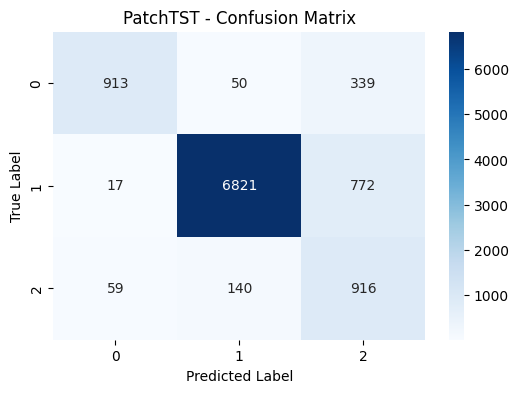

Model saved successfully!


In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model.eval()
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)
all_preds = []
all_targets = []
with torch.no_grad():
    for bx, by in test_loader:
        bx, by = bx.to(device), by.to(device)
        out = model(bx)
        _, preds = torch.max(out, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(by.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_targets)
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print('\nTest Classification Report:')
print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('PatchTST - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
torch.save(model.state_dict(), '../models/patchtst_model.pth')
print('Model saved successfully!')

# Controlled Epoch Evaluation Experiment
*(Added automatically per rigorous experiment protocol)*

In [6]:
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, recall_score, log_loss
import tensorflow as tf
import os

# Reproducibility Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Loading Data and Splitting Chronologically per Feeder...")
X_train_unscaled = np.load('../dataset/X_train.npy')
y_train_full = np.load('../dataset/y_train_full.npy')
X_train_scaled = np.load('../dataset/X_train_scaled.npy')

sub_col = 13
fdr_col = 14
TIME_STEPS = 5

train_seq_X, train_seq_y = [], []
val_seq_X, val_seq_y = [], []

unique_feeders = np.unique(X_train_unscaled[:, [sub_col, fdr_col]], axis=0)

for feeder in unique_feeders:
    mask = (X_train_unscaled[:, sub_col] == feeder[0]) & (X_train_unscaled[:, fdr_col] == feeder[1])
    idx = np.where(mask)[0]
    
    n = len(idx)
    split_idx = int(n * 0.8)
    
    train_idx = idx[:split_idx]
    val_idx = idx[split_idx:]
    
    for i in range(len(train_idx) - TIME_STEPS):
        train_seq_X.append(X_train_scaled[train_idx[i : i + TIME_STEPS]])
        train_seq_y.append(y_train_full[train_idx[i + TIME_STEPS]])
        
    for i in range(len(val_idx) - TIME_STEPS):
        val_seq_X.append(X_train_scaled[val_idx[i : i + TIME_STEPS]])
        val_seq_y.append(y_train_full[val_idx[i + TIME_STEPS]])

X_train_3D = np.array(train_seq_X)
y_train_seq = np.array(train_seq_y)
X_val_3D = np.array(val_seq_X)
y_val_seq = np.array(val_seq_y)

X_test_3D = np.load('../dataset/X_test_3D.npy')
y_test_seq = np.load('../dataset/y_test.npy')

c_in = X_train_3D.shape[2]
seq_len = X_train_3D.shape[1]
c_out = 3

Loading Data and Splitting Chronologically per Feeder...


In [7]:
def calculate_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    high_risk_recall = recall_score(y_true, y_pred, labels=[2], average='macro')
    if np.isnan(high_risk_recall): high_risk_recall = 0.0
    loss = log_loss(y_true, y_prob) if y_prob is not None else 0.0
    return acc, macro_f1, high_risk_recall, loss

results = []
EPOCHS = 50
CHECKPOINTS = [10, 20, 30, 40, 50]

In [8]:
print(f"\n--- Controlled Experiment: PatchTST ---")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_tensor_X = torch.tensor(X_train_3D, dtype=torch.float32)
train_tensor_y = torch.tensor(y_train_seq, dtype=torch.long)
val_tensor_X = torch.tensor(X_val_3D, dtype=torch.float32).to(device)
val_tensor_y = torch.tensor(y_val_seq, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(train_tensor_X, train_tensor_y), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor_X, val_tensor_y), batch_size=512, shuffle=False)

# Assuming the model class is named PatchTST (or TemporalFusionTransformer for TFT)
class_name = 'TemporalFusionTransformer' if 'PatchTST' == 'TFT' else 'PatchTST'
model_exp = globals()[class_name](c_in, c_out, seq_len).to(device)
# Transformers use AdamW generally, LSTMs use Adam
opt_class = optim.AdamW if 'PatchTST' in ['TimesNet', 'PatchTST'] else optim.Adam
optimizer = opt_class(model_exp.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

start_time = time.time()
os.makedirs(f'../models/checkpoints/PatchTST', exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model_exp.train()
    total_loss, correct, total = 0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model_exp(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * bx.size(0)
        correct += (out.argmax(dim=1) == by).sum().item()
        total += bx.size(0)
        
    if epoch in CHECKPOINTS:
        elapsed = time.time() - start_time
        train_loss = total_loss / total
        train_acc = correct / total
        
        model_exp.eval()
        val_preds, val_probs = [], []
        with torch.no_grad():
            for bx, by in val_loader:
                out = model_exp(bx)
                prob = torch.softmax(out, dim=1)
                val_probs.extend(prob.cpu().numpy())
                val_preds.extend(out.argmax(dim=1).cpu().numpy())
        
        val_acc, val_f1, val_hr_rec, val_loss = calculate_metrics(y_val_seq, val_preds, val_probs)
        
        results.append({
            'model': 'PatchTST', 'epoch': epoch,
            'train_loss': train_loss, 'val_loss': val_loss,
            'train_accuracy': train_acc, 'val_accuracy': val_acc,
            'val_macro_f1': val_f1, 'val_high_risk_recall': val_hr_rec,
            'training_time': elapsed
        })
        torch.save(model_exp.state_dict(), f'../models/checkpoints/PatchTST/epoch_{epoch}.pth')
        print(f"Epoch {epoch}: Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}, High-Risk Rec: {val_hr_rec:.4f}")

df_new = pd.DataFrame(results)
csv_path = '../results/epoch_experiment_results.csv'
os.makedirs('../results', exist_ok=True)
if os.path.exists(csv_path):
    df_new.to_csv(csv_path, mode='a', header=False, index=False)
else:
    df_new.to_csv(csv_path, index=False)
print("Results appended to epoch_experiment_results.csv")


--- Controlled Experiment: PatchTST ---


C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Epoch 10: Val Loss: 0.0768, Val F1: 0.8152, High-Risk Rec: 0.4387


C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Epoch 20: Val Loss: 0.0945, Val F1: 0.8103, High-Risk Rec: 0.4416


C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Epoch 30: Val Loss: 0.1168, Val F1: 0.8007, High-Risk Rec: 0.4160


C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Epoch 40: Val Loss: 0.1333, Val F1: 0.8202, High-Risk Rec: 0.4815
Epoch 50: Val Loss: 0.1402, Val F1: 0.8008, High-Risk Rec: 0.4074
Results appended to epoch_experiment_results.csv


C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
